In [1]:
import pandas as pd

english = pd.read_csv(
    "../../data/poptrag_lyrics_genres_corpus_filtered_english_lemmatized.csv"
)

In [ ]:
from lingua import Language, LanguageDetectorBuilder

detector = LanguageDetectorBuilder.from_languages(
    Language.ENGLISH, Language.GERMAN
).build()


def english_confidence(lyrics: str) -> float:
    """Returns lingua's confidence score for English."""
    results = detector.compute_language_confidence_values(lyrics)
    for r in results:
        if r.language == Language.ENGLISH:
            return r.value
    return 0.0


english["english_conf"] = english["lyrics_lemmatized"].apply(english_confidence)

# Single-pass filter: keep tracks where English confidence exceeds threshold
# Exclude schlager/classical as before
english_filtered = english.query(
    "english_conf >= 0.5 and not cat32 == 'schlager' and not cat32 == 'classical'"
)

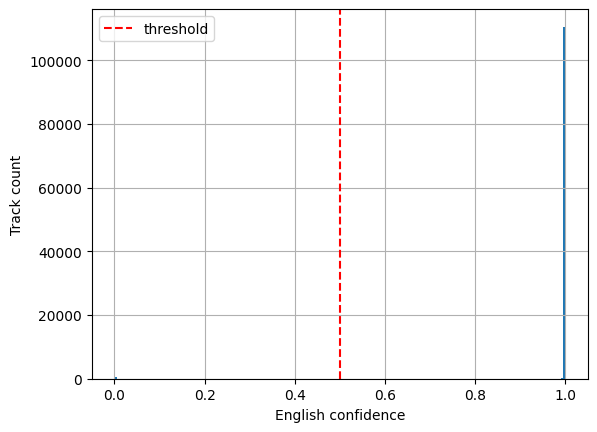

In [31]:
import matplotlib.pyplot as plt

english["english_conf"].hist(bins=200)
plt.xlabel("English confidence")
plt.ylabel("Track count")
plt.axvline(0.5, color="red", linestyle="--", label="threshold")
plt.legend()

In [60]:
lookup = english.query("english_conf < 0.75 or is_english == False")
print(f"Number of tracks with English confidence < 0.9: {len(lookup)}")

table = lookup.groupby("cat32").size()
table.sort_values(ascending=False)

Number of tracks with English confidence < 0.9: 1433


cat32
hip hop              376
electronic           290
pop                  207
rock                 143
metal                 82
reggae                55
alternative rock      36
classical             30
jazz                  24
indie rock            16
new wave              16
power metal           14
r&b                   14
soul                  14
heavy metal           12
hard rock             11
folk                  11
punk                  10
pop rock               9
synth-pop              9
house                  9
progressive rock       8
blues                  7
dance-pop              6
folk rock              6
singer-songwriter      5
blues rock             4
classic rock           3
death metal            3
soft rock              2
country                1
dtype: int64

In [54]:
test = english.copy()
test.rename(columns={"track.s.firstartist.name": "artist"}, inplace=True)
check = test.query("artist == 'Kollegah' & english_conf < 0.5 & is_english == True")

In [4]:
import nltk
import numpy as np
import matplotlib.pyplot as plt

english_vocab = set(w.lower() for w in nltk.corpus.words.words())


def is_english_vocab(lyrics: str, vocab_threshold: float = 0.6) -> bool:
    words = [w.lower() for w in lyrics.split() if w.lower().isalpha()]
    if len(words) == 0:
        return False
    ratio = sum(1 for w in words if w in english_vocab) / len(words)
    return ratio >= vocab_threshold

threshold_grid: [0.4        0.41153846 0.42307692 0.43461538 0.44615385 0.45769231
 0.46923077 0.48076923 0.49230769 0.50384615 0.51538462 0.52692308
 0.53846154 0.55       0.56153846 0.57307692 0.58461538 0.59615385
 0.60769231 0.61923077 0.63076923 0.64230769 0.65384615 0.66538462
 0.67692308 0.68846154 0.7        0.71153846 0.72307692 0.73461538
 0.74615385 0.75769231 0.76923077 0.78076923 0.79230769 0.80384615
 0.81538462 0.82692308 0.83846154 0.85      ]
Applying vocab threshold: 0.4
Applying vocab threshold: 0.4115384615384616
Applying vocab threshold: 0.4230769230769231
Applying vocab threshold: 0.4346153846153846
Applying vocab threshold: 0.4461538461538462
Applying vocab threshold: 0.45769230769230773
Applying vocab threshold: 0.46923076923076923
Applying vocab threshold: 0.4807692307692308
Applying vocab threshold: 0.49230769230769234
Applying vocab threshold: 0.5038461538461538
Applying vocab threshold: 0.5153846153846154
Applying vocab threshold: 0.5269230769230769
Applying

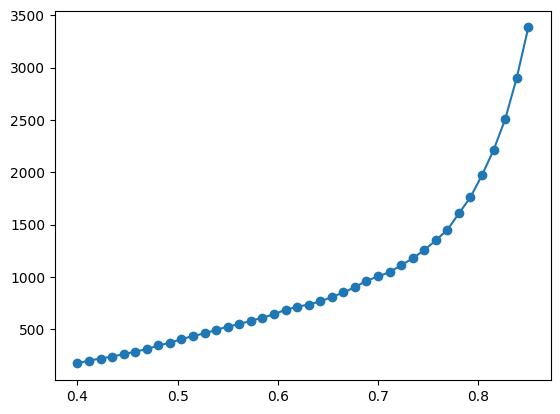

In [ ]:
# Idetify the optimal threhold for filtering non-english tracks by elbow method
threshold_grid = np.linspace(0.4, 0.85, 40)
print("threshold_grid:", threshold_grid)
results = []
for thresh in threshold_grid:
    print(f"Applying vocab threshold: {thresh}")
    english["is_english"] = english["lyrics_lemmatized"].apply(
        is_english_vocab, vocab_threshold=thresh
    )
    filterd_vocab = english.query("is_english == False")["lyrics_lemmatized"]
    results.append(filterd_vocab.shape[0])

plt.plot(threshold_grid, results, marker="o")

# Filter mostly non-English tracks

In [6]:
import nltk

english_vocab = set(w.lower() for w in nltk.corpus.words.words())
english["is_english"] = english["lyrics_lemmatized"].apply(
    is_english_vocab, vocab_threshold=0.75
)

filtered_songs = english.query("is_english == False and not cat32 == 'schlager' and not cat32 == 'classical'")
filtered_counts = filtered_songs["cat32"].value_counts()
full_counts = english["cat32"].value_counts()
print("relative freuquency of filtered tracks: ")
round(filtered_counts/full_counts*100, 0).sort_values(ascending=False)

english_filtered = english.query("is_english == True")

relative freuquency of filtered tracks: 


# Expand contractions

In [ ]:
import re

CONTRACTIONS: dict[str, str] = {
    # be
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'd": "i would",
    "you'd": "you would",
    "he'd": "he would",
    "she'd": "she would",
    "we'd": "we would",
    "they'd": "they would",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will",
    # negations
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "couldn't": "could not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "mightn't": "might not",
    "needn't": "need not",
    # wh-contractions
    "what's": "what is",
    "what're": "what are",
    "what've": "what have",
    "where's": "where is",
    "who's": "who is",
    "who'd": "who would",
    "who'll": "who will",
    "that's": "that is",
    "there's": "there is",
    "there're": "there are",
    "here's": "here is",
    # informal
    "ain't": "is not",
    "everybody's": "everybody is",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "outta": "out of",
    "lotta": "lot of",
    "inna": "in a",
    "gimmie": "give me",
    "imma": "i am going to",
    "ima": "i am going to",
    "i'ma": "i am going to",
    "coulda": "could have",
    "shoulda": "should have",
    "woulda": "would have",
    "musta": "must have",
    "lemme": "let me",
    "gimme": "give me",
    "tryna": "trying to",
    "finna": "fixing to",
    "bout": "about",
    "'cause": "because",
    "cuz": "because",
    "'em": "them",
    "ya": "you",
    "til": "until",
    "'til": "until",
}

# Build a single compiled regex for efficiency
_CONTRACTION_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in CONTRACTIONS) + r")\b",
    flags=re.IGNORECASE,
)


def expand_contractions(text: str) -> str:
    def _replace(match: re.Match) -> str:
        token = match.group(0)
        replacement = CONTRACTIONS[token.lower()]
        # Preserve capitalisation of first letter
        return replacement.capitalize() if token[0].isupper() else replacement

    return _CONTRACTION_RE.sub(_replace, text)


# Apply to corpus before lemmatization
filtered_songs["lyrics_lemmatized"] = filtered_songs["lyrics_lemmatized"].map(
    expand_contractions
)

# Improve small domain lexicon by inspecting the most common non-english words


In [74]:
import numpy as np
import nltk
from helpers.extractor_utils import extract_ngrams

# tokens is (sparse_matrix, vocab_list) from extract_ngrams
X, vocab = extract_ngrams(
    filtered_songs["lyrics_lemmatized"], order=1, name="unigram", random_state=42
)

# Sum occurrences across all documents
word_freqs = np.asarray(X.sum(axis=0)).flatten()
vocab_arr = np.array(vocab)

# Sort by frequency descending
order = np.argsort(word_freqs)[::-1]
sorted_words = vocab_arr[order]
sorted_freqs = word_freqs[order]

# Keep only words NOT in the NLTK english_vocab and not in the NLKT german_vocab
oov_mask = np.array([w not in english_vocab for w in sorted_words])
oov_words = sorted_words[oov_mask]
oov_freqs = sorted_freqs[oov_mask]


# Inspect top N candidates
print(len(oov_words), "OOV words found.")
top_n = 100000
oov_candidates = list(zip(oov_words[:top_n], oov_freqs[:top_n]))
oov_candidates

Extracted unigram:
  - Unique: 22,998
  - Shape: (1116, 22998)
  - Examples: ['wölfe', 'correct', 'anruf', 'interimo', 'har']
17177 OOV words found.


[('ooh', np.int64(2010)),
 ('doo', np.int64(1269)),
 ('und', np.int64(1063)),
 ('du', np.int64(873)),
 ('der', np.int64(749)),
 ('wie', np.int64(660)),
 ('ja', np.int64(573)),
 ('auf', np.int64(534)),
 ('nicht', np.int64(515)),
 ('uh', np.int64(509)),
 ('mit', np.int64(492)),
 ('ein', np.int64(417)),
 ('dem', np.int64(362)),
 ('im', np.int64(355)),
 ('oo', np.int64(354)),
 ('que', np.int64(344)),
 ('mich', np.int64(328)),
 ('zu', np.int64(318)),
 ('nur', np.int64(294)),
 ('für', np.int64(293)),
 ('pum', np.int64(281)),
 ('fuck', np.int64(281)),
 ('wenn', np.int64(269)),
 ('von', np.int64(255)),
 ('doch', np.int64(255)),
 ('nah', np.int64(250)),
 ('gimmie', np.int64(242)),
 ('le', np.int64(229)),
 ('hab', np.int64(220)),
 ('au', np.int64(201)),
 ('meine', np.int64(191)),
 ('denn', np.int64(177)),
 ('bist', np.int64(175)),
 ('mm', np.int64(167)),
 ('keine', np.int64(162)),
 ('ihr', np.int64(161)),
 ('noch', np.int64(160)),
 ('aber', np.int64(159)),
 ('mach', np.int64(158)),
 ('je', np.in